In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")

if OPENAI_API_KEY:
    print("OpenAI API key loaded successfully!")
else:
    print('WARNING: No OpenAI API key found.Please set it in your .env file.')


OpenAI API key loaded successfully!


#### Step2: Creaate BigCompany Inc.'s 'Database'

In [2]:
# order records
# ============================================================
# BigCompany Inc.'s "Database" (simulated with dictionaries)
# ============================================================

# Order records
ORDERS_DB = {
    "ORD-1001": {
        "customer": "Alice Johnson",
        "product": "Laptop Pro 15",
        "price": 1299.99,
        "status": "delivered",
        "delivery_date": "2026-02-05",
    },
    "ORD-1002": {
        "customer": "Bob Smith",
        "product": "Wireless Headphones X3",
        "price": 199.99,
        "status": "shipped",
        "estimated_delivery": "2026-02-14",
    },
    "ORD-1003": {
        "customer": "Carol Davis",
        "product": "Smartphone Ultra 12",
        "price": 899.99,
        "status": "processing",
        "estimated_delivery": "2026-02-18",
    },
}

# Return/refund policy
RETURN_POLICY = {
    "standard_return_window": "30 days from delivery",
    "refund_processing_time": "5-7 business days",
    "conditions": [
        "Item must be in original packaging",
        "Item must not show signs of damage caused by the customer",
        "Proof of purchase (order ID) is required",
    ],
    "non_returnable": ["Earbuds (hygiene reasons)", "Software licenses"],
}

print("BigCompany Inc. database loaded!")
print(f"  - {len(ORDERS_DB)} orders in the system")
print(f"  - Return policy: {RETURN_POLICY['standard_return_window']}")

BigCompany Inc. database loaded!
  - 3 orders in the system
  - Return policy: 30 days from delivery


In [3]:
from langchain_core.tools import tool

@tool
def  check_order_status(order_id: str) -> str:

    """ Check the current status of a cusstomer order.
    Use this tool when a customer asks about their order status,
    delivery date, or order details.

    Args: 
        order rder_id: The order ID (e.g., 'ORD-1001').
    """
    order = ORDERS_DB.get(order_id)

    if not order :
        return f"order '{order_id}' not found. Please check the order ID and try again."

    info = f"Order {order_id}:\n"
    info += f"  Customer: {order['customer']}\n"
    info += f"  Product: {order['product']}\n"
    info += f"  Price: ${order['price']}\n"
    info += f"  Status: {order['status']}\n"

    if order["status"] == "delivered":
        info += f"  Delivered on: {order['delivery_date']}"
    else:
        info += f"  Estimated delivery: {order['estimated_delivery']}"

    return info


@tool
def lookup_return_policy() -> str:
    """Look up BigCompany Inc.'s return and refund policy.

    Use this tool when a customer asks about returns, refunds,
    or the return policy.
    """
    policy = "BigCompany Inc. Return Policy:\n"
    policy += f"  Return window: {RETURN_POLICY['standard_return_window']}\n"
    policy += f"  Refund processing: {RETURN_POLICY['refund_processing_time']}\n"
    policy += "  Conditions:\n"
    for condition in RETURN_POLICY["conditions"]:
        policy += f"    - {condition}\n"
    policy += "  Non-returnable items:\n"
    for item in RETURN_POLICY["non_returnable"]:
        policy += f"    - {item}\n"
    return policy


@tool
def process_return_request(order_id: str, reason: str) -> str:
    """Process a return request for a customer order.

    Use this tool when a customer confirms they want to return a product.
    Only use this AFTER checking the order status and confirming
    the customer wants to proceed.

    Args:
        order_id: The order ID to process the return for.
        reason: The customer's reason for returning the product.
    """
    order = ORDERS_DB.get(order_id)

    if not order:
        return f"Cannot process return: Order '{order_id}' not found."

    if order["status"] != "delivered":
        return (
            f"Cannot process return: Order {order_id} has status '{order['status']}'. "
            f"Returns can only be processed for delivered orders."
        )

    return (
        f"Return request APPROVED for order {order_id} ({order['product']}).\n"
        f"  Reason: {reason}\n"
        f"  Refund amount: ${order['price']}\n"
        f"  Refund will be processed within {RETURN_POLICY['refund_processing_time']}.\n"
        f"  A return shipping label has been sent to the customer's email."
    )


# Collect all tools in a list — we'll give this to the LLM
tools = [check_order_status, lookup_return_policy, process_return_request]

print("Tools created:")
for t in tools:
    print(f"  - {t.name}: {t.description[:60]}...")

Tools created:
  - check_order_status: Check the current status of a cusstomer order.
   Use this t...
  - lookup_return_policy: Look up BigCompany Inc.'s return and refund policy.

    Use...
  - process_return_request: Process a return request for a customer order.

    Use this...


In [4]:
from langchain_openai import ChatOpenAI

# Initialize the LLM
# - model: "gpt-4o-mini" is fast and affordable, great for customer service
# - temperature: 0 means deterministic responses (no randomness)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Give the LLM access to our tools
# After this, the LLM knows about check_order_status, lookup_return_policy, etc.
# and can decide to call them when needed.
llm_with_tools = llm.bind_tools(tools)

# The system prompt: the agent's "job description"
SYSTEM_PROMPT = """You are a friendly and helpful customer service agent for BigCompany Inc., \
an online electronics store.

Your responsibilities:
- Help customers check their order status.
- Answer questions about our return and refund policy.
- Process return requests when customers want to return a product.
- Be polite, empathetic, and professional at all times.

Important guidelines:
- Always greet the customer warmly.
- When a customer asks about an order, use the check_order_status tool.
- When a customer asks about returns or refunds, use the lookup_return_policy tool.
- Before processing a return, always confirm with the customer first.
- If you cannot help with something, let the customer know you will \
connect them with a human agent.
- Keep responses concise but helpful.
"""

print("LLM initialized with tools!")
print(f"Model: gpt-4o-mini")
print(f"Available tools: {[t.name for t in tools]}")

LLM initialized with tools!
Model: gpt-4o-mini
Available tools: ['check_order_status', 'lookup_return_policy', 'process_return_request']


In [5]:
from langgraph.graph import MessagesState

# MessagesState already provides:
#   messages: Annotated[list[AnyMessage], add_messages]
#
# The add_messages reducer means:
#   - When a node returns {"messages": [new_message]},
#     the new message is APPENDED to the existing list
#   - The full conversation history is always available

# That's it! For our simple agent, MessagesState is all we need.
# No custom state class required.

print("State defined: Using MessagesState (built-in)")
print("  - Tracks: messages (full conversation history)")

State defined: Using MessagesState (built-in)
  - Tracks: messages (full conversation history)


#### STEP6: 

In [6]:
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode


# Node 1: The Assistant
# This is where the LLM "thinks" about the conversation and decides what to do.
def assistant(state: MessagesState):
    # Prepend the system prompt to give the LLM its instructions
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]

    # Call the LLM with the full conversation + available tools
    response = llm_with_tools.invoke(messages)

    # Return the LLM's response to be added to the conversation
    return {"messages": [response]}


# Node 2: The Tool Executor
# ToolNode automatically:
#   - Reads tool_calls from the last AI message
#   - Executes the requested tools
#   - Returns ToolMessage(s) with the results
tool_node = ToolNode(tools)

print("Nodes defined:")
print("  1. 'assistant' — calls the LLM to think and respond")
print("  2. 'tools'     — executes tool calls requested by the LLM")

Nodes defined:
  1. 'assistant' — calls the LLM to think and respond
  2. 'tools'     — executes tool calls requested by the LLM


#### Step7:

In [7]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import InMemorySaver

# Create a new graph with our state definition
builder = StateGraph(MessagesState)

# --- Add Nodes ---
builder.add_node("assistant", assistant)
builder.add_node("tools", tool_node)

# --- Add Edges ---

# 1. Start → Assistant: every conversation begins at the assistant node
builder.add_edge(START, "assistant")

# 2. Assistant → (conditional): after the LLM responds, check if it wants to use a tool
#    - If the LLM's response contains tool_calls → go to "tools" node
#    - If not (it's a final answer) → go to END
builder.add_conditional_edges("assistant", tools_condition)

# 3. Tools → Assistant: after executing tools, go back to the assistant
#    so the LLM can use the tool results to form its response
builder.add_edge("tools", "assistant")

# --- Compile the Graph ---
# InMemorySaver gives our agent conversation memory
# (in production, you'd use PostgresSaver for persistence)
memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

print("Graph compiled successfully!")
print("\nWorkflow:")
print("  START → assistant → [tools_condition] → tools → assistant → ... → END")

Graph compiled successfully!

Workflow:
  START → assistant → [tools_condition] → tools → assistant → ... → END


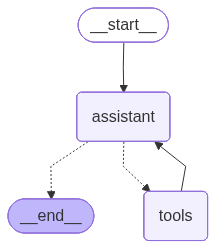

In [8]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
from langchain_core.messages import HumanMessage


def chat(user_message: str, thread_id: str = "customer-session-1"):
    """Send a message to the BigCompany Inc. support agent and display the response."""

    print(f"\n{'='*60}")
    print(f"Customer: {user_message}")
    print(f"{'='*60}")

    # thread_id keeps track of the conversation
    # same thread_id = same conversation (agent remembers previous messages)
    config = {"configurable": {"thread_id": thread_id}}

    # Stream the response so we can see each step
    for chunk in graph.stream(
        {"messages": [HumanMessage(content=user_message)]},
        config,
        stream_mode="updates",
    ):
        # Show which node is executing and what it produced
        for node_name, update in chunk.items():
            last_msg = update["messages"][-1]

            if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
                # The LLM is requesting a tool call
                for tc in last_msg.tool_calls:
                    print(f"\n[Agent is calling tool: {tc['name']}({tc['args']})]")

            elif node_name == "tools":
                # Tool results are coming back
                print(f"\n[Tool result received]")

            else:
                # Final response from the agent
                print(f"\nAgent: {last_msg.content}")


print("Chat helper ready! Use chat('your message') to talk to the agent.")

Chat helper ready! Use chat('your message') to talk to the agent.


In [10]:
chat("Hi! I need some help with my order.")


Customer: Hi! I need some help with my order.

Agent: Hello! I'm here to help you. Could you please provide me with your order ID so I can check the status for you?


In [11]:
chat("Can you check the status of my order ORD-1002?")


Customer: Can you check the status of my order ORD-1002?

[Agent is calling tool: check_order_status({'order_id': 'ORD-1002'})]

[Tool result received]

Agent: Your order **ORD-1002** for the **Wireless Headphones X3** has been shipped! The estimated delivery date is **February 14, 2026**. 

If you have any more questions or need further assistance, feel free to ask!


In [12]:
chat("When will it arrive?")


Customer: When will it arrive?

Agent: Your order is estimated to arrive on **February 14, 2026**. If you have any other questions or need assistance with anything else, just let me know!


In [13]:
chat("What is your return policy?")


Customer: What is your return policy?

[Agent is calling tool: lookup_return_policy({})]

[Tool result received]

Agent: Here’s our return policy:

- **Return Window:** You have 30 days from the delivery date to return an item.
- **Refund Processing:** Refunds are processed within 5-7 business days.
- **Conditions:**
  - The item must be in its original packaging.
  - The item must not show signs of damage caused by the customer.
  - Proof of purchase (your order ID) is required.

**Non-returnable items** include:
- Earbuds (for hygiene reasons)
- Software licenses

If you have any specific questions or need to process a return, just let me know!


In [14]:
chat(
    "Hi, I'd like to return my Laptop Pro 15. My order ID is ORD-1001. "
    "The screen has a dead pixel.",
    thread_id="customer-session-2",
)


Customer: Hi, I'd like to return my Laptop Pro 15. My order ID is ORD-1001. The screen has a dead pixel.

[Agent is calling tool: check_order_status({'order_id': 'ORD-1001'})]

[Tool result received]

Agent: Your order for the Laptop Pro 15 has been delivered. Since you mentioned that it has a dead pixel, I can help you process the return. 

Would you like to proceed with the return for this reason?


In [15]:
chat(
    "Yes, please go ahead and process the return.",
    thread_id="customer-session-2",
)


Customer: Yes, please go ahead and process the return.

[Agent is calling tool: process_return_request({'order_id': 'ORD-1001', 'reason': 'Dead pixel on the screen'})]

[Tool result received]

Agent: Your return request for the Laptop Pro 15 has been approved! 

- **Reason:** Dead pixel on the screen
- **Refund Amount:** $1299.99
- **Refund Processing Time:** Within 5-7 business days
- A return shipping label has been sent to your email.

If you have any further questions or need assistance, feel free to ask!


In [16]:
chat(
    "What's the status of order ORD-9999?",
    thread_id="customer-session-3",
)


Customer: What's the status of order ORD-9999?

[Agent is calling tool: check_order_status({'order_id': 'ORD-9999'})]

[Tool result received]

Agent: Hello! It seems that order ID "ORD-9999" is not found in our system. Please double-check the order ID and provide it again, or let me know if you need assistance with anything else!


In [17]:
# Let's inspect the state of customer-session-2 (the return conversation)
config = {"configurable": {"thread_id": "customer-session-2"}}
state = graph.get_state(config)

print("Conversation history for customer-session-2:")
print(f"Total messages: {len(state.values['messages'])}\n")

for i, msg in enumerate(state.values["messages"]):
    msg_type = type(msg).__name__
    content = msg.content[:100] if msg.content else "[tool call]"
    print(f"  Message {i+1} ({msg_type}): {content}")

Conversation history for customer-session-2:
Total messages: 8

  Message 1 (HumanMessage): Hi, I'd like to return my Laptop Pro 15. My order ID is ORD-1001. The screen has a dead pixel.
  Message 2 (AIMessage): Hello! I'm sorry to hear about the issue with your Laptop Pro 15. Before we proceed with the return,
  Message 3 (ToolMessage): Order ORD-1001:
  Customer: Alice Johnson
  Product: Laptop Pro 15
  Price: $1299.99
  Status: deliv
  Message 4 (AIMessage): Your order for the Laptop Pro 15 has been delivered. Since you mentioned that it has a dead pixel, I
  Message 5 (HumanMessage): Yes, please go ahead and process the return.
  Message 6 (AIMessage): [tool call]
  Message 7 (ToolMessage): Return request APPROVED for order ORD-1001 (Laptop Pro 15).
  Reason: Dead pixel on the screen
  Ref
  Message 8 (AIMessage): Your return request for the Laptop Pro 15 has been approved! 

- **Reason:** Dead pixel on the scree
